In [1]:
import tensorflow as tf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
%matplotlib inline
route = 'best_model_gpa.keras'
route_imp = 'best_model_gpa_imp.keras'

I0000 00:00:1780286450.616621   25232 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1780286450.795961   25232 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1780286455.414996   25232 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [2]:
df_test = pd.read_csv("dataset/teen_test_clean.csv")
df_test.head(3)

,age,daily_social_media_hours,sleep_hours,screen_time_before_sleep,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,gender_male,platform_usage_Instagram,platform_usage_TikTok,target_academic_performance
0,-0.423604,0.964649,1.138136,0.358302,0.499566,1.299343,0.885630,-1.278894,-1.257485,1,0,0,3.89
1,-1.414248,-0.320794,-1.354196,-0.202138,-0.707584,1.299343,0.190450,0.125439,-0.200096,1,0,0,2.02
2,-0.423604,-0.914076,-0.731113,-0.202138,-1.224935,1.299343,-1.199909,0.125439,0.857292,1,1,0,2.34


In [3]:
df_train = pd.read_csv("dataset/teen_train_clean.csv")
df_train.head(3)

,age,daily_social_media_hours,sleep_hours,screen_time_before_sleep,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,gender_male,platform_usage_Instagram,platform_usage_TikTok,target_academic_performance
0,-0.423604,-0.864636,-0.246493,1.619290,1.361817,0.064324,0.190450,-0.927811,0.50483,1,0,1,2.98
1,1.062363,-1.408478,-0.592650,-0.482357,-0.017784,1.299343,-0.852319,-0.927811,0.50483,1,0,0,2.85
2,-0.918926,0.569128,0.168896,1.198960,1.361817,1.299343,1.580809,1.529772,0.50483,0,1,0,2.35


In [4]:
y_test = df_test['target_academic_performance']
df_test = df_test.drop(columns=['target_academic_performance'])
X_test = df_test.copy()
y_test.head()

0    3.89
1    2.02
2    2.34
3    2.05
4    3.39
Name: target_academic_performance, dtype: float64

In [5]:
X_test.head()

,age,daily_social_media_hours,sleep_hours,screen_time_before_sleep,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,gender_male,platform_usage_Instagram,platform_usage_TikTok
0,-0.423604,0.964649,1.138136,0.358302,0.499566,1.299343,0.885630,-1.278894,-1.257485,1,0,0
1,-1.414248,-0.320794,-1.354196,-0.202138,-0.707584,1.299343,0.190450,0.125439,-0.200096,1,0,0
2,-0.423604,-0.914076,-0.731113,-0.202138,-1.224935,1.299343,-1.199909,0.125439,0.857292,1,1,0
3,1.062363,-1.012957,-1.284964,0.638521,-0.535134,0.064324,1.233219,-0.225644,1.562218,1,0,1
4,-1.414248,1.656812,1.622756,0.778631,-0.880035,-1.170695,-1.547498,1.178689,-0.905022,1,1,0


In [6]:
y_train = df_train['target_academic_performance']
df_train = df_train.drop(columns=['target_academic_performance'])
X_train = df_train.copy()
y_train.head()

0    2.98
1    2.85
2    2.35
3    3.50
4    3.09
Name: target_academic_performance, dtype: float64

In [7]:
X_train.head()

,age,daily_social_media_hours,sleep_hours,screen_time_before_sleep,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,gender_male,platform_usage_Instagram,platform_usage_TikTok
0,-0.423604,-0.864636,-0.246493,1.619290,1.361817,0.064324,0.190450,-0.927811,0.504830,1,0,1
1,1.062363,-1.408478,-0.592650,-0.482357,-0.017784,1.299343,-0.852319,-0.927811,0.504830,1,0,0
2,-0.918926,0.569128,0.168896,1.198960,1.361817,1.299343,1.580809,1.529772,0.504830,0,1,0
3,-0.423604,-0.518555,1.622756,0.078082,-0.362684,-1.170695,-0.852319,0.125439,-0.905022,1,0,0
4,-1.414248,0.618568,-0.108030,-0.902687,-0.190234,0.064324,0.885630,-0.576727,1.209755,0,1,0


In [8]:
BATCH_SIZE = 32

X_train_final, X_val, y_train_final, y_val = train_test_split(
    X_train, y_train.values, test_size=0.15
)

train_pipeline = tf.data.Dataset.from_tensor_slices((X_train_final, y_train_final))
train_pipeline = train_pipeline.shuffle(buffer_size=len(X_train_final)).batch(BATCH_SIZE)

val_dataset = tf.data.Dataset.from_tensor_slices((X_val, y_val)).batch(BATCH_SIZE)
test_dataset = tf.data.Dataset.from_tensor_slices((X_test.to_numpy(), y_test.to_numpy())).batch(BATCH_SIZE)

E0000 00:00:1780286461.015153   25232 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [9]:
checkpoint_callback = ModelCheckpoint(
    filepath=route,       
    monitor='val_loss',         
    save_best_only=True,        
    mode='min',                 
    verbose=1                   
)

early_stop = EarlyStopping(
    monitor='val_loss', 
    patience=15, 
    restore_best_weights=True
)

In [10]:
input_shape_dim = X_train.shape[1]
model = Sequential([
   Input(shape=(input_shape_dim,)),
    Dense(256, activation='relu'),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(1)
])

model.compile(
    optimizer='adam',             
    loss='mse',                   
    metrics=['mae', tf.keras.metrics.RootMeanSquaredError(name='rmse')]       
)

In [11]:
history = model.fit(
    train_pipeline,
    epochs=100, 
    validation_data=val_dataset,
    callbacks=[checkpoint_callback, early_stop],
    verbose=1)

Epoch 1/100
20/26 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 5.2922 - mae: 2.0472 - rmse: 2.2530
Epoch 1: val_loss improved from None to 0.53213, saving model to best_model_gpa.keras

Epoch 1: finished saving model to best_model_gpa.keras
26/26 ━━━━━━━━━━━━━━━━━━━━ 4s 31ms/step - loss: 2.4416 - mae: 1.2561 - rmse: 1.5626 - val_loss: 0.5321 - val_mae: 0.5851 - val_rmse: 0.7295
Epoch 2/100
21/26 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.6328 - mae: 0.6481 - rmse: 0.7950
Epoch 2: val_loss improved from 0.53213 to 0.42543, saving model to best_model_gpa.keras

Epoch 2: finished saving model to best_model_gpa.keras
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.5604 - mae: 0.6130 - rmse: 0.7486 - val_loss: 0.4254 - val_mae: 0.5127 - val_rmse: 0.6522
Epoch 3/100
22/26 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.4560 - mae: 0.5493 - rmse: 0.6746
Epoch 3: val_loss did not improve from 0.42543
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.4889 - mae: 0.5749 - rmse: 0.6992 - val_loss: 0.4363

In [12]:
test_loss, test_mae, test_rmse = model.evaluate(test_dataset, verbose=1)

print(f"\nTest MSE (Loss): {test_loss:.4f}")
print(f"Test MAE: {test_mae:.4f}")
print(f"Test RMSE: {test_rmse:.4f}")

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.4332 - mae: 0.5484 - rmse: 0.6581 

Test MSE (Loss): 0.4332
Test MAE: 0.5484
Test RMSE: 0.6581


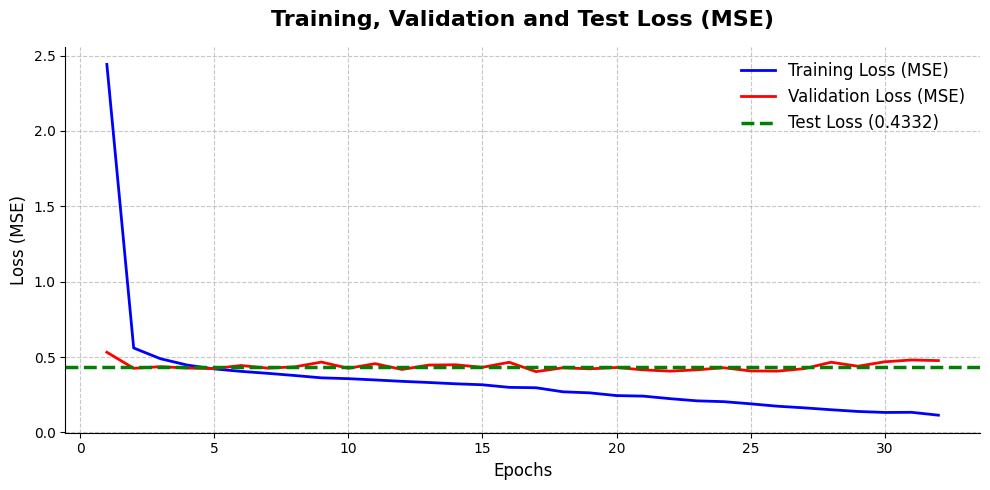

In [13]:
epochs = range(1, len(history.history['loss']) + 1)
train_loss = history.history['loss']
val_loss = history.history['val_loss']

plt.figure(figsize=(10, 5))

plt.plot(epochs, train_loss, 'b-', label='Training Loss (MSE)', linewidth=2)
plt.plot(epochs, val_loss, 'r-', label='Validation Loss (MSE)', linewidth=2)
plt.axhline(y=test_loss, color='g', linestyle='--', label=f'Test Loss ({test_loss:.4f})', linewidth=2.5)

# Títulos y e
plt.title('Training, Validation and Test Loss (MSE)', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss (MSE)', fontsize=12)
plt.legend(frameon=False, fontsize=12)

# Estilo limpio solo con Matplotlib (fondo con cuadrícula clara y sin bordes superior/derecho)
plt.grid(True, linestyle='--', alpha=0.7)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

# Mostrar la gráfica
plt.tight_layout()
plt.show()

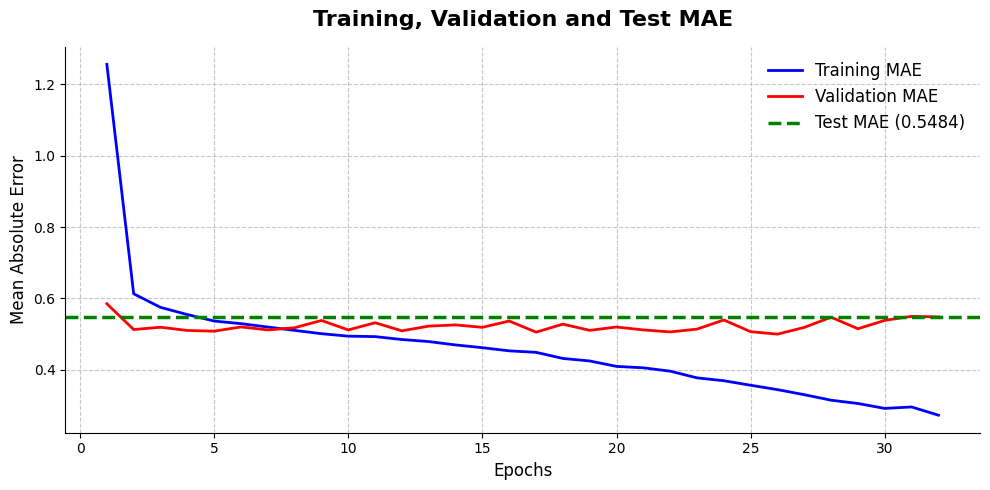

In [14]:
epochs = range(1, len(history.history['mae']) + 1)
train_mae = history.history['mae']
val_mae = history.history['val_mae']

plt.figure(figsize=(10, 5))

plt.plot(epochs, train_mae, 'b-', label='Training MAE', linewidth=2)
plt.plot(epochs, val_mae, 'r-', label='Validation MAE', linewidth=2)
plt.axhline(y=test_mae, color='g', linestyle='--', label=f'Test MAE ({test_mae:.4f})', linewidth=2.5)

plt.title('Training, Validation and Test MAE', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Mean Absolute Error', fontsize=12)
plt.legend(frameon=False, fontsize=12)

plt.grid(True, linestyle='--', alpha=0.7)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

In [15]:
final_train_loss = history.history['loss'][-1]
final_val_loss = history.history['val_loss'][-1]

final_train_mae = history.history['mae'][-1]
final_val_mae = history.history['val_mae'][-1]

final_train_rmse = history.history['rmse'][-1]
final_val_rmse = history.history['val_rmse'][-1]

data = {
    'Métrica': ['MSE (Loss)', 'MAE', 'RMSE'],
    'Train': [final_train_loss, final_train_mae, final_train_rmse],
    'Validation': [final_val_loss, final_val_mae, final_val_rmse],
    'Test': [test_loss, test_mae, test_rmse]
}

df_metrics = pd.DataFrame(data).round(4)
df_metrics

,Métrica,Train,Validation,Test
0,MSE (Loss),0.1146,0.4766,0.4332
1,MAE,0.2727,0.5482,0.5484
2,RMSE,0.3385,0.6904,0.6581


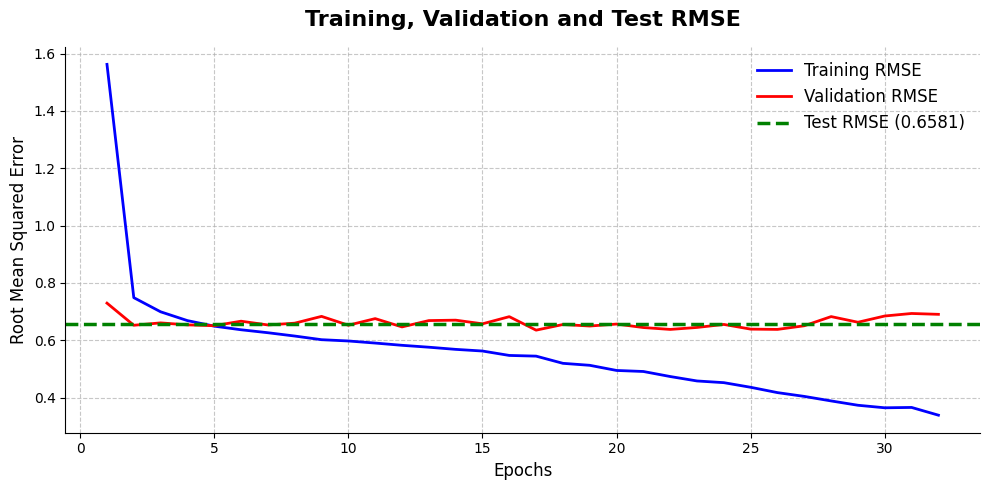

In [16]:
epochs = range(1, len(history.history['rmse']) + 1)
train_rmse = history.history['rmse']
val_rmse = history.history['val_rmse']

plt.figure(figsize=(10, 5))

plt.plot(epochs, train_rmse, 'b-', label='Training RMSE', linewidth=2)
plt.plot(epochs, val_rmse, 'r-', label='Validation RMSE', linewidth=2)

plt.axhline(y=test_rmse, color='g', linestyle='--', label=f'Test RMSE ({test_rmse:.4f})', linewidth=2.5)

plt.title('Training, Validation and Test RMSE', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Root Mean Squared Error', fontsize=12)
plt.legend(frameon=False, fontsize=12)

plt.grid(True, linestyle='--', alpha=0.7)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

In [17]:
model_imp = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(12,)),
    
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.3), 
    
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dropout(0.3),
    
    tf.keras.layers.Dense(32, activation='relu'),    
    
    tf.keras.layers.Dense(1)
])

In [18]:
checkpoint_callback_imp = ModelCheckpoint(
    filepath=route_imp,       
    monitor='val_loss',         
    save_best_only=True,        
    mode='min',                 
    verbose=1                   
)

In [19]:
optimizer = tf.keras.optimizers.AdamW(learning_rate=0.001, weight_decay=1e-4)

model_imp.compile(
    optimizer=optimizer,             
    loss='mse',                   
    metrics=['mae', tf.keras.metrics.RootMeanSquaredError(name='rmse')]       
)

In [20]:
history_imp = model_imp.fit(
    train_pipeline,
    epochs=100, 
    validation_data=val_dataset,
    callbacks=[checkpoint_callback_imp, early_stop],
    verbose=1)

Epoch 1/100
22/26 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 7.0517 - mae: 2.5131 - rmse: 2.6407
Epoch 1: val_loss improved from None to 0.61325, saving model to best_model_gpa_imp.keras

Epoch 1: finished saving model to best_model_gpa_imp.keras
26/26 ━━━━━━━━━━━━━━━━━━━━ 5s 28ms/step - loss: 4.2905 - mae: 1.8077 - rmse: 2.0714 - val_loss: 0.6133 - val_mae: 0.6347 - val_rmse: 0.7831
Epoch 2/100
23/26 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.1192 - mae: 0.8426 - rmse: 1.0563
Epoch 2: val_loss did not improve from 0.61325
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 1.0478 - mae: 0.8163 - rmse: 1.0236 - val_loss: 0.6609 - val_mae: 0.6387 - val_rmse: 0.8129
Epoch 3/100
22/26 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.8183 - mae: 0.7197 - rmse: 0.9035
Epoch 3: val_loss improved from 0.61325 to 0.49865, saving model to best_model_gpa_imp.keras

Epoch 3: finished saving model to best_model_gpa_imp.keras
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.8778 - mae: 0.7447 - rmse: 0.9369 - 

In [21]:
test_loss, test_mae, test_rmse = model_imp.evaluate(test_dataset, verbose=1)

print(f"\nTest MSE (Loss): {test_loss:.4f}")
print(f"Test MAE: {test_mae:.4f}")
print(f"Test RMSE: {test_rmse:.4f}")

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.5795 - mae: 0.6177 - rmse: 0.7612 

Test MSE (Loss): 0.5795
Test MAE: 0.6177
Test RMSE: 0.7612


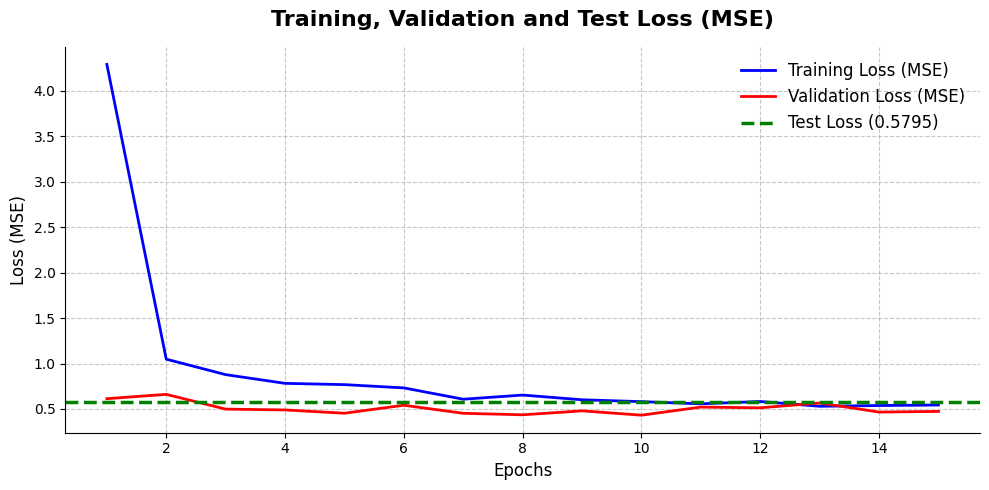

In [22]:
epochs = range(1, len(history_imp.history['loss']) + 1)
train_loss = history_imp.history['loss']
val_loss = history_imp.history['val_loss']

plt.figure(figsize=(10, 5))

plt.plot(epochs, train_loss, 'b-', label='Training Loss (MSE)', linewidth=2)
plt.plot(epochs, val_loss, 'r-', label='Validation Loss (MSE)', linewidth=2)
plt.axhline(y=test_loss, color='g', linestyle='--', label=f'Test Loss ({test_loss:.4f})', linewidth=2.5)

plt.title('Training, Validation and Test Loss (MSE)', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss (MSE)', fontsize=12)
plt.legend(frameon=False, fontsize=12)

plt.grid(True, linestyle='--', alpha=0.7)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

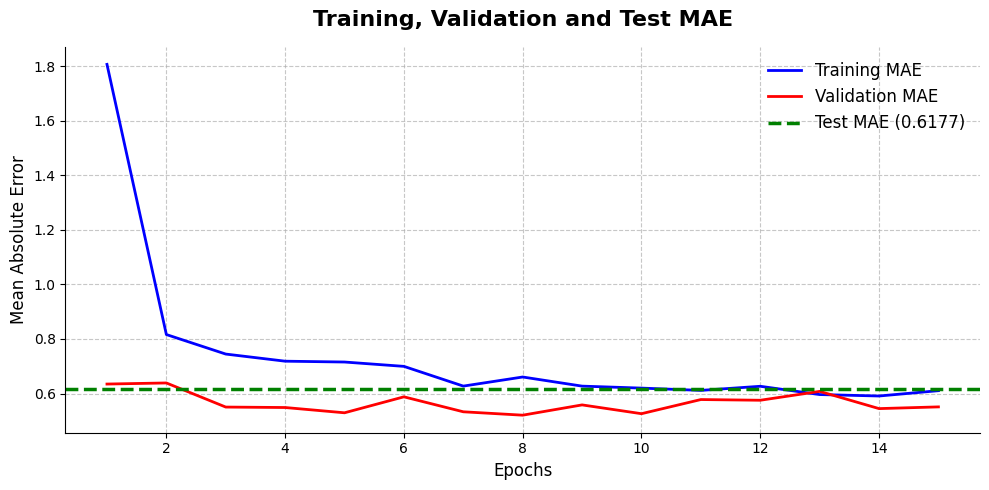

In [23]:
epochs = range(1, len(history_imp.history['mae']) + 1)
train_mae = history_imp.history['mae']
val_mae = history_imp.history['val_mae']

plt.figure(figsize=(10, 5))

plt.plot(epochs, train_mae, 'b-', label='Training MAE', linewidth=2)
plt.plot(epochs, val_mae, 'r-', label='Validation MAE', linewidth=2)
plt.axhline(y=test_mae, color='g', linestyle='--', label=f'Test MAE ({test_mae:.4f})', linewidth=2.5)

plt.title('Training, Validation and Test MAE', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Mean Absolute Error', fontsize=12)
plt.legend(frameon=False, fontsize=12)

plt.grid(True, linestyle='--', alpha=0.7)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

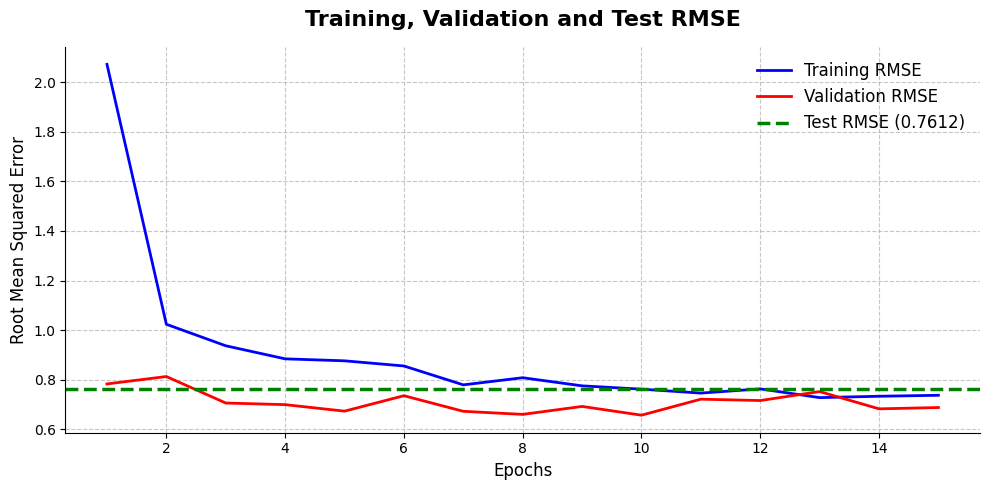

In [24]:
epochs = range(1, len(history_imp.history['rmse']) + 1)
train_rmse = history_imp.history['rmse']
val_rmse = history_imp.history['val_rmse']

plt.figure(figsize=(10, 5))

plt.plot(epochs, train_rmse, 'b-', label='Training RMSE', linewidth=2)
plt.plot(epochs, val_rmse, 'r-', label='Validation RMSE', linewidth=2)

plt.axhline(y=test_rmse, color='g', linestyle='--', label=f'Test RMSE ({test_rmse:.4f})', linewidth=2.5)

plt.title('Training, Validation and Test RMSE', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Root Mean Squared Error', fontsize=12)
plt.legend(frameon=False, fontsize=12)

plt.grid(True, linestyle='--', alpha=0.7)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

In [25]:
final_train_loss = history_imp.history['loss'][-1]
final_val_loss = history_imp.history['val_loss'][-1]

final_train_mae = history_imp.history['mae'][-1]
final_val_mae = history_imp.history['val_mae'][-1]

final_train_rmse = history_imp.history['rmse'][-1]
final_val_rmse = history_imp.history['val_rmse'][-1]

data = {
    'Métrica': ['MSE (Loss)', 'MAE', 'RMSE'],
    'Train': [final_train_loss, final_train_mae, final_train_rmse],
    'Validation': [final_val_loss, final_val_mae, final_val_rmse],
    'Test': [test_loss, test_mae, test_rmse]
}

df_metrics = pd.DataFrame(data).round(4)
df_metrics

,Métrica,Train,Validation,Test
0,MSE (Loss),0.5437,0.4733,0.5795
1,MAE,0.6104,0.5509,0.6177
2,RMSE,0.7374,0.6880,0.7612
